In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import numpy as np
from matplotlib import pyplot as plt

import pint, logging
pint.logging.setup(level="ERROR")
logging.getLogger('enterprise').setLevel(logging.ERROR)

from pint.fitter import Fitter
from pint.models import get_model, get_model_and_toas
from pint.residuals import Residuals
from pint.simulation import make_fake_toas_uniform

from astropy import units as u
from copy import deepcopy
from tqdm import tqdm

path = '../../datasets/NG15'

In [2]:
# Choose one pulsar to test on
par = path +'/par/J0740+6620_PINT_DMX.par'
tim = path +'/tim/J0740+6620_PINT_DMX.tim'

model, toas = get_model_and_toas(par, tim)
fit = pint.fitter.Fitter.auto(toas, model)
fit.fit_toas()
M, labels, units = fit.get_designmatrix()
fit_values = np.array([0]+[fit.model[l].value for l in labels[1:]])
fit_uncert = np.array([1]+[fit.model[l].uncertainty_value for l in labels[1:]])


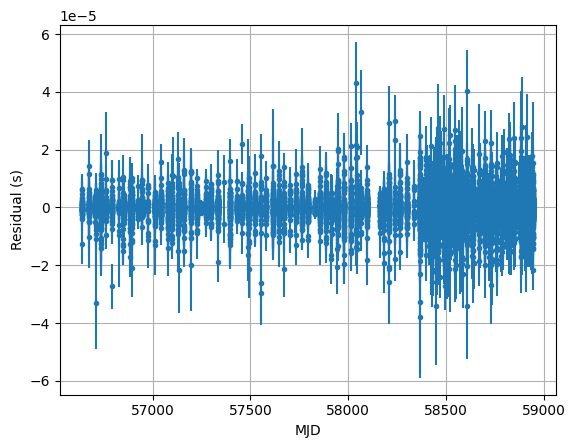

In [3]:
residuals = Residuals(fit.toas, fit.model)

toas = fit.toas.get_mjds().value
r = residuals.time_resids.to(u.s).value
sigma = residuals.toas.get_errors().to(u.s).value
ntoa = len(toas)


plt.errorbar(toas, r, yerr=sigma, fmt=".")
plt.xlabel("MJD")
plt.ylabel("Residual (s)")
plt.grid()
plt.show()

ELONG


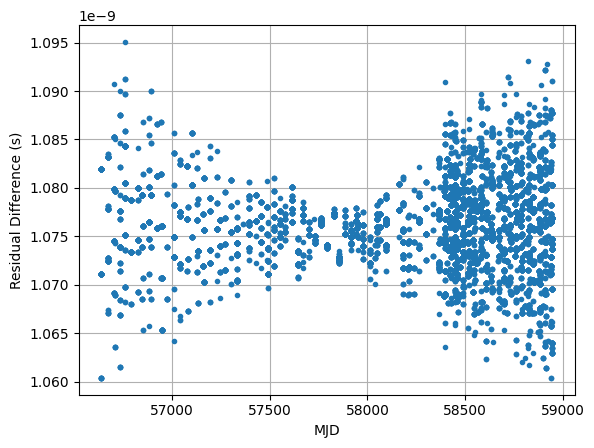

In [4]:
def perturb_deterministic_model(label, epsilon):
    dmodel = deepcopy(fit.model)

    dval = dmodel[label].value * np.asarray(epsilon).item()
    dmodel[label].value += dval

    dres = Residuals(fit.toas, dmodel)
    r = dres.time_resids.to(u.s).value

    return r

def perturb_linear_model(label, epsilon):
    idx = labels.index(label)

    dval = fit.model[label].value * np.asarray(epsilon).item()
    r = residuals.time_resids.to(u.s).value - dval * M[:,idx]

    return r

def q_statistic(label, epsilon):
    dr = perturb_deterministic_model(label, epsilon)
    lr = perturb_linear_model(label, epsilon)
    Q = np.sum(( (dr-lr)/sigma )**2)/ntoa
    return Q


l = labels[2]
print(l)
dr = perturb_deterministic_model(l, 1e-10)
lr = perturb_linear_model(l, 1e-10)

plt.plot(residuals.toas.get_mjds(), dr-lr, ".")
plt.xlabel("MJD")
plt.ylabel("Residual Difference (s)")
plt.grid()
plt.show()

In [5]:
Q = q_statistic(l, 1e-8)
Q

np.longdouble('0.0061113978790294197594')

If Q is less than 1, then the noise in the linear approximation is less than the noise in the residuals, and the linear approximation is valid. If Q is greater than 1, then the noise in the linear approximation is greater than the noise in the residuals, and the linear approximation is not valid.

In [6]:
from scipy.optimize import brentq


def find_epsilon(label, x0, q_target=1):
    foo = lambda x: q_statistic(label, x) - q_target
    # We know that using x=0 gives Q=0 -> foo(0) = -q_target
    # need to find x0 which gives Q>q_target -> foo(x) > 0
    max_iter = 20
    for i in range(max_iter): # To span 20 orders of magnitude
        if foo(x0) > 0:
            break
        else:
            x0 *= 10 # Increase by an order of magnitude until we find a value that gives Q>q_target

        if i == max_iter - 1:
            raise ValueError("Failed to find an x0 that gives Q > q_target")

    # Now we have a bracket for the root, we can use brentq to find the root
    epsilon = brentq(foo, 0, x0) # Epsilon where Q approx 1
    return epsilon


# For each parameter, find the negative and positive epsilon with Q=1
epsilons = np.zeros((len(labels),2)) # negative, positive
for i in tqdm(range(len(labels))):
    if i==0:
        continue # skip the offset parameter
    l = labels[i]

    try:
        eps_n = find_epsilon(l, x0=-fit_uncert[i])
        eps_p = find_epsilon(l, x0=-1.1*eps_n) # use the negative epsilon as a guess!
    except ValueError:
        eps_n = np.nan
        eps_p = np.nan

    epsilons[i] = [eps_n, eps_p]

    

100%|██████████| 129/129 [43:04<00:00, 20.04s/it]


In [7]:
for i,l in enumerate(labels):
    print(l, epsilons[i], epsilons[i]/sigma[i])

Offset [0. 0.] [0. 0.]
PX [-1.35525301  1.35525301] [-215393.04019428  215393.03965429]
ELONG [-1.27917107e-07  1.27917441e-07] [-0.02715286  0.02715293]
ELAT [-1.48854468e-07  1.48854466e-07] [-0.04031811  0.04031811]
PMELONG [-1.37781126  1.37781127] [-379248.90113604  379248.90452506]
PMELAT [-0.24775343  0.24775344] [-65508.57545585  65508.57724444]
F0 [nan nan] [nan nan]
F1 [-0.0001433  0.0001433] [-13.41921881  13.4192185 ]
JUMP1 [-0.00194471  0.00194471] [-153.36815143  153.36815143]
DMX_0001 [-124.87380994  124.87380996] [-21280472.04241728  21280472.04517094]
DMX_0002 [-102.97733709  102.97733708] [-33641730.50931077  33641730.50499225]
DMX_0003 [-140.06861742  140.06861741] [-47626187.49546359  47626187.49095479]
DMX_0004 [-711.74936165  711.74936163] [-1.26062586e+08  1.26062586e+08]
DMX_0005 [-17.73055533  17.73055532] [-4342531.30729879  4342531.30602363]
DMX_0006 [-469.48065212  469.4806521 ] [-98485557.39817193  98485557.39501205]
DMX_0007 [-12.44159481  12.44159481] [-2